In [1]:
from matplotlib import pyplot as plt
import numpy as np
import deepRD.tools.trajectoryTools as trajectoryTools


def g_method_xdu(vv_corr, xdu_corr, dt, mass, trunc):
    """Gmethod with external potential."""
    trunc = np.min([len(vv_corr), len(xdu_corr), trunc])
    kernel_i = np.zeros(trunc)
    prefac = 2.0 / (vv_corr[0] * dt)
    for i in range(1, len(kernel_i)):
        # analytically, the difference between mass * vv_corr and xdu_corr is zero,
        # as they are both equal to kbt. Numerically, it helps to keep it in, though.
        kernel_i[i] = mass * (vv_corr[0] - vv_corr[i]) + xdu_corr[i] - xdu_corr[0]
        conv = np.sum(kernel_i[:i] * vv_corr[::-1][len(vv_corr) - i - 1 : -1])
        kernel_i[i] -= dt * conv
        kernel_i[i] *= prefac
    return kernel_i


def g_method_xdu_nomass(vv_corr, xdu_corr, dt, trunc):
    """Compute the integral over the kernel, computes mass via FDT"""
    trunc = np.min([len(vv_corr), len(xdu_corr), trunc])
    kernel_i = np.zeros(trunc)
    prefac = 2.0 / vv_corr[0]
    for i in range(1, trunc):
        kernel_i[i] = prefac * (
            (xdu_corr[i] - vv_corr[i] * xdu_corr[0] / vv_corr[0]) / dt
            - np.sum(kernel_i[1:i] * vv_corr[1:i][::-1])
        )
    return kernel_i

def correlation_fft(a, b, trunc):
    """Calculates correlation via FFT."""
    len_a = len(a)
    a = np.concatenate([a, np.zeros(len_a)])
    b = np.concatenate([b, np.zeros(len_a)])
    a_fft = np.fft.fft(a)
    b_fft = np.fft.fft(b)
    corr = np.fft.ifft(a_fft * np.conj(b_fft))
    corr = corr[:trunc].real
    corr /= np.linspace(len_a, len_a - trunc + 1, trunc)
    return corr

In [91]:
systemType='dimer'
# Datasets directory
localDirectory = f"/group/ag_cmb/scratch/maojrs/stochasticClosure/{systemType}/boxsize5/benchmark/"

#  Loading trajectories.
n_trajs = 20
fnums = np.random.choice(2500, n_trajs, replace=False)
dataset=None

for f_num in fnums:
    try:
        ds = trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)[np.newaxis, :]
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = np.concatenate((dataset, ds), axis=0)
        
print('Trajectories loaded.')
dataset.shape

Trajectories loaded.


(20, 20000, 11)

In [31]:
# Calculating Autocorrelation Functions

lagtimesteps = 200


ACF_M = trajectoryTools.calculateAutoCorrelationFunction(dataset, lagtimesteps, var='velocity')
vels = dataset[:, :, 4:7]

# ACF by FFT for 1-D traj, then summing up over vector dimensions and all trajs 
ACF_FFT = np.zeros(lagtimesteps)
for vel in vels:
    ACF_FFT += np.sum([correlation_fft(vel[:, i], vel[:, i], lagtimesteps) for i in range(vel.shape[1])], axis=0)
    

ACF_FFT /= ACF_FFT[0]

<function matplotlib.pyplot.show(close=None, block=None)>

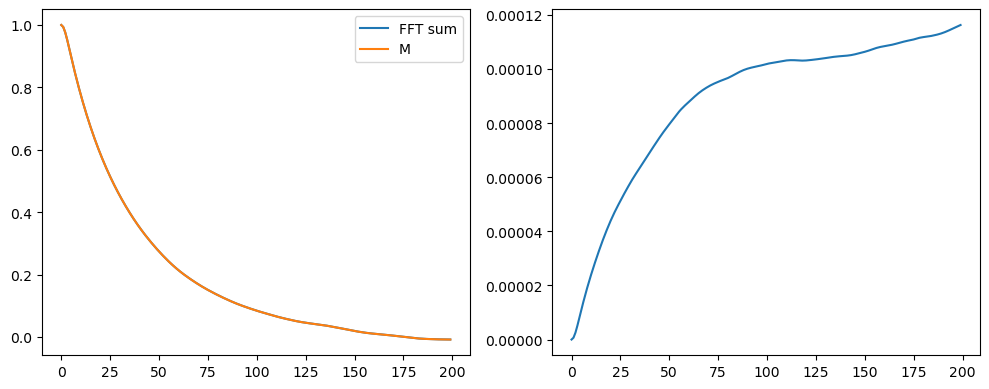

In [32]:
# Plotting comparison for ACFs

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].plot(ACF_FFT, label='FFT sum')
axes[0].plot(ACF_M, label='M')
axes[1].plot(ACF_FFT-ACF_M)
axes[0].legend()
plt.tight_layout()
plt.show

In [ ]:
# Comparing ACF for analitically computed vels and numerically differentiated

vels = np.diff(trajs) / dt

(20, 10000) (20, 10000) (20, 9999)
[0.17863377 0.17947807 0.18482463 ... 1.92302698 1.92623908 1.92801116] [0.8322642  0.84228632 0.84279112 0.84439846 0.85126695 0.85303058
 0.85718045 0.86163093 0.86453218 0.8647328 ]


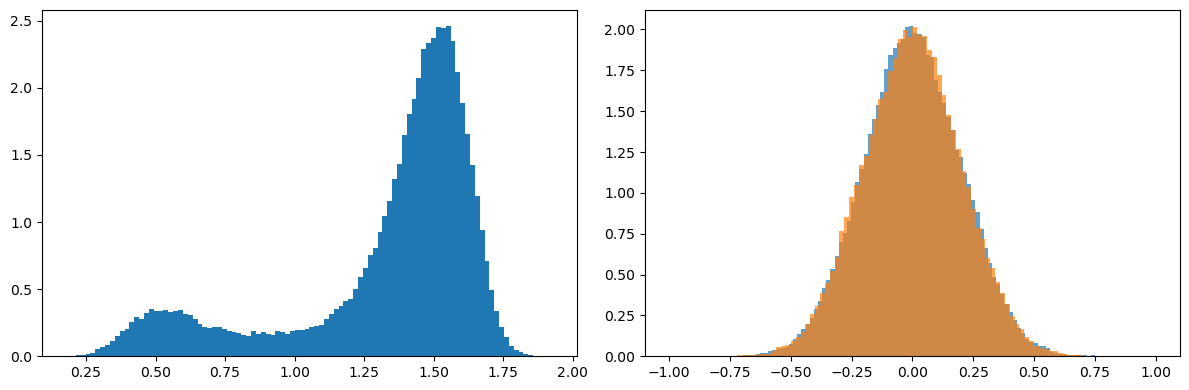

In [92]:
dt = 0.05

if systemType=='dimer':
    q1 = dataset[:, ::2, 1:4]
    q2 = dataset[:, 1::2, 1:4]
    v1 = dataset[:, ::2, 4:7]
    v2 = dataset[:, 1::2, 4:7]

    boxsize=5
    
    # relative distance and velocity
    dq = np.zeros((q1.shape[0], q1.shape[1]))
    dp = np.zeros((v1.shape[0], v1.shape[1]))
    relVels = np.zeros(v1.shape)
    
    for i in range(q1.shape[0]):
        for j in range(q1.shape[1]):
            relPos = trajectoryTools.relativePosition(q1[i,j], q2[i,j], 'periodic', 5)
            relVel = v1[i,j] - v2[i,j]
            relVels[i,j] = relVel
            
            normRelPos = np.linalg.norm(relPos)
            unitRelPos = relPos / normRelPos
            axisRelVel = np.dot(relVel, unitRelPos)
            
            dq[i,j] = normRelPos
            dp[i,j] = axisRelVel
    
    trajs = dq
    vels = dp
    
elif systemType=='harmonic':
    q = dataset[:, :, 1:4]
    v = dataset[:, :, 4:7]

    trajs = np.linalg.norm(q, axis=2)
    vels = np.zeros(trajs.shape)
    
    for i in range(q.shape[0]):
        for j in range(q.shape[1]):
            vels[i,j] = np.dot(v[i,j], q[i,j])/trajs[i,j]

else:
    trajs = None
    vels = None
    
vels2 = np.diff(trajs) / dt

print(trajs.shape, vels.shape, vels2.shape)

#vv_corrs2 = trajectoryTools.calculateAutoCorrelationFunction(dataset, 200, var='velocity')

if isinstance(trajs,np.ndarray):

    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].hist(trajs.flatten(), bins=100, density=True)
    axes[1].hist(vels2.flatten(), bins=100, density=True, alpha=0.7)
    axes[1].hist(vels.flatten(), bins=100, range=(-1,1), density=True, alpha=0.7)
    plt.tight_layout()
    plt.show

    print(np.sort(trajs.flatten()), np.sort(np.abs(vels.flatten()))[-10:])

In [93]:
dt_mult = 1

dt = 0.05
kbt = 1
trunc = int(10 / dt)

# 3-D Correlation
if systemType=='harmonic':
    vv_corr3 = trajectoryTools.calculateAutoCorrelationFunction(dataset, trunc, var='velocity')
elif systemType=='dimer':
    vv_corr3 = trajectoryTools.calculateAutoCorrelationFunction(dataset[:, ::2, :] - dataset[:, 1::2, :], trunc, var='velocity')

vv_corr4 = np.zeros(lagtimesteps)
for i in range(dataset.shape[0]):
    if systemType=='harmonic':
        vel = dataset[i, :, 4:7]
    elif systemType=='dimer':
        v1 = dataset[i, ::2, 4:7]
        v2 = dataset[i, 1::2, 4:7]
        vel = v1-v2
        
    vv_corr4 += np.sum([correlation_fft(vel[:, j], vel[:, j], trunc) for j in range(vel.shape[1])], axis=0)

# 1-D Correlation
vv_corrs = [] # FFT
vv_corrs2 = [] # Differentiated vels, FFT

xdu_corrs = []
skipped = 0 

for traj, vel, vel2 in zip(trajs, vels, vels2):
    vv_corr = correlation_fft(vel, vel, trunc)
    vv_corr2 = correlation_fft(vel2, vel2, trunc)
    #del vel
    # we could use this, more accurate: du = kharm * traj
    # for arbitrary potential

    hist_x, bins = np.histogram(traj, bins=150)
    bins = 0.5 * (bins[1:] + bins[:-1])

    if 0 in hist_x:
        skipped +=1
        continue
    
    fe = -kbt * np.log(hist_x)

    grad_fe = np.gradient(fe, bins) 
    du = np.interp(traj, bins, grad_fe)
    xdu_corr = correlation_fft(traj, du, trunc)

    vv_corrs.append(vv_corr)
    vv_corrs2.append(vv_corr2)
    xdu_corrs.append(xdu_corr)

print(vel.shape, du.shape, vv_corr.shape, xdu_corr.shape, vv_corr2.shape)
print('skipped', skipped, 'trajs')

vv_corr = np.average(np.array(vv_corrs), axis=0)
vv_corr2 = np.average(np.array(vv_corrs2), axis=0)
xdu_corr = np.average(np.array(xdu_corrs), axis=0)

vv_corr /= vv_corr[0]
vv_corr2 /= vv_corr2[0]
vv_corr4 /= vv_corr4[0]

kernel_int = g_method_xdu_nomass(
    trunc=trunc,
    dt=dt,
    vv_corr=vv_corr,
    xdu_corr=xdu_corr,
)
kernel_int = kernel_int

(10000,) (10000,) (200,) (200,) (200,)complete   
skipped 5 trajs


<function matplotlib.pyplot.show(close=None, block=None)>

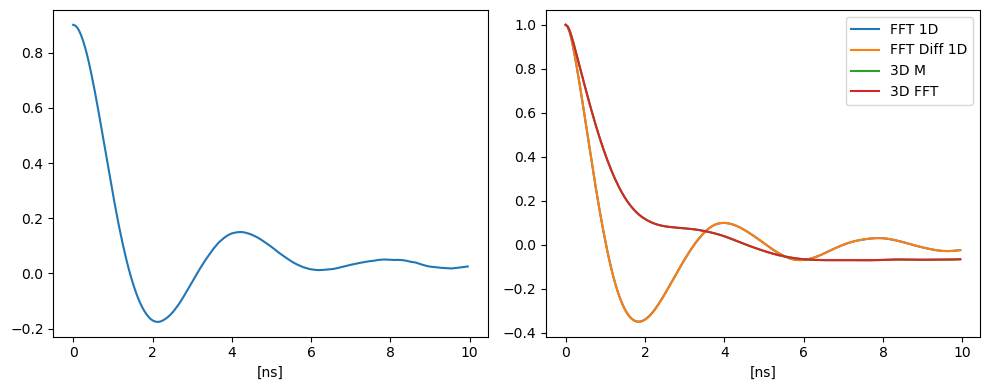

In [97]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].plot(np.arange(trunc)*dt, xdu_corr)
axes[0].set_xlabel('[ns]')
axes[1].plot(np.arange(trunc)*dt, vv_corr, label = 'FFT 1D')
axes[1].plot(np.arange(trunc)*dt, vv_corr2, label = 'FFT Diff 1D')
axes[1].plot(np.arange(trunc)*dt, vv_corr3, label ='3D M')
axes[1].plot(np.arange(trunc)*dt, vv_corr4, label = '3D FFT')
axes[1].set_xlabel('[ns]')
axes[1].legend()
plt.tight_layout()
plt.show

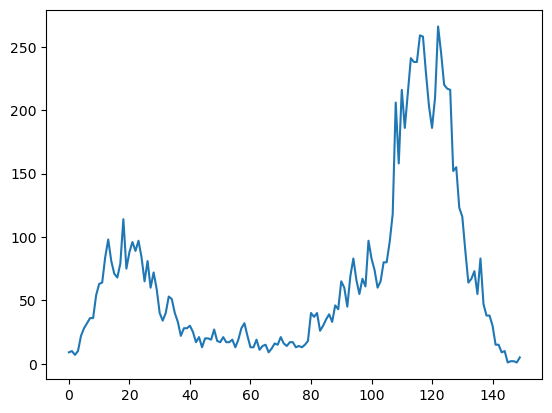

In [98]:
plt.plot(hist_x)
#print(np.log(hist_x), len(hist_x))

(200,)


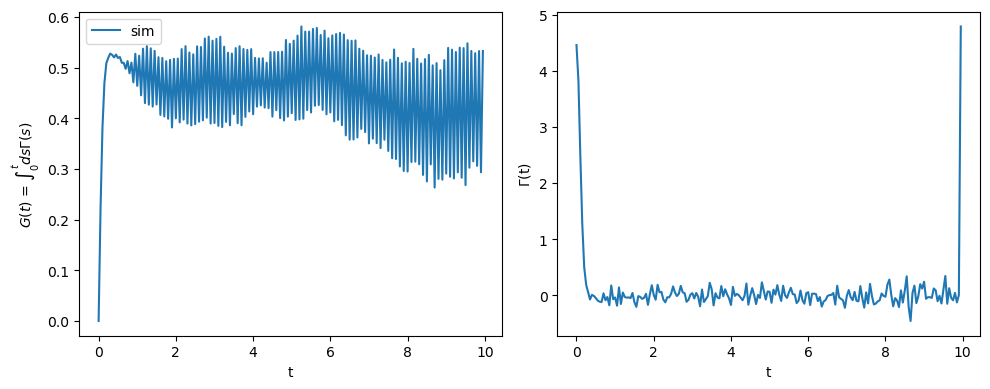

In [99]:
_fig, axes = plt.subplots(1, 2, figsize=(10,4))
time = np.arange(trunc) * dt
print(time.shape)
#kernel_ref = get_kernel_ref(time, gammas, taus)
#kernel_int_ref = get_kernel_integral_ref(time, gammas, taus)
axes[1].plot(time, np.gradient(kernel_int, dt), label="sim")
#axes[0].plot(time, kernel_ref, label="ref")
axes[0].plot(time, kernel_int, label="sim")
#axes[1].plot(time, kernel_int_ref, label="ref")
axes[1].set(xlabel="t", ylabel=r"$\Gamma$(t)")
axes[0].set(xlabel="t", ylabel=r"$G(t)$ = $\int_0^t ds \Gamma(s)$")
axes[0].legend()
plt.tight_layout()
plt.show()

In [490]:
print(kernel_int[:10], vv_corr[:10], xdu_corr[:10])

[ 0.         11.72920377 17.0577313  22.3163992  22.7136505  24.58648708
 23.24029398 24.4973776  22.85583919 24.10690971] [0.02010949 0.01994781 0.01955553 0.01902537 0.0184288  0.01781597
 0.01721235 0.01662729 0.01606309 0.0155197 ] [0.7659359  0.76567439 0.76511071 0.76434485 0.76343478 0.76244942
 0.76139887 0.76029961 0.75909152 0.75779064]
